# Boosting & Clustering: From-Scratch Implementations

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, mean_squared_error

In [3]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_s_curve
from sklearn.datasets import make_swiss_roll, make_circles
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Boosting

## Gradient Boosting From Scratch

Implement gradient boosting for regression. Quick recap of the **core formulas**.

Let the current ensemble at step $N-1$ be $a_{N - 1}(x_i)$. The next base learner $b_N(x_i)$ is trained to predict $-\frac{\partial L(y_i, z)}{\partial z}\Bigl|_{z = a_{N - 1}(x_i)}$, where $L(y_i, z)$ is the loss on an object with true value $y_i$ and prediction $z$. The ensemble at the next step is then:

$$
a_N(x_i) = a_{N-1}(x_i) + \nu\gamma_Nb_N(x_i)
$$

Here $\nu$ is the learning-rate hyperparameter, and $\gamma_N$ is the optimal weight tuned at each step, found via (note there's no $\nu$ here):

$$
\gamma_N = \mathrm{arg}\min_\gamma \frac{1}{\ell}\sum\limits_{i=1}^{\ell}L\left(y_i, a_{N - 1}(x_i) + \gamma b_N(x_i)\right)
$$

$\gamma_N = 1$ for every $N$ is an acceptable simplification.


In [4]:
from scipy.optimize import minimize

In [6]:
class GradientBoosting1:
    def __init__(self, n_estimators, max_depth, learning_rate=0.1):
        """
        PARAMETERS:
        n_estimators - number of trees in the ensemble
        max_depth - maximum depth of a tree
        learning_rate - coefficient by which new algorithm result is multiplied
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.trees = []

    def fit(self, x, y):
        """
        INPUT:
        x - np.array of shape (k, d)
        y - np.array of shape (k,)
        """
        # Need to iterate over n_estimators and train that many trees via _fit_predict_tree(),
        # updating y_new correctly along the way.
        # The trees need to be stored somewhere so they can be used later in predict()
        y_old = np.zeros(y.shape[0])
        for i in range(0, self.n_estimators):

            smth = self._fit_predict_tree(x, y - y_old)
            y_new = y_old + smth
            y_old = y_new
        return self

    def _fit_predict_tree(self, x, y):
        # Train a tree and return its prediction

        tree = DecisionTreeRegressor(max_depth = self.max_depth)

        self.trees.append(tree.fit(x,y))
        self.gamma = 1
        return self.gamma * self.learning_rate * tree.predict(x)

    def predict(self, x):
        """
        INPUT:
        x - np.array of shape (m, d)
        OUTPUT:
        y_pred - np.array of shape (m,)
        """
        # Use the stored trees to compute the aggregated prediction
        y_pred = np.zeros(x.shape[0])
        for i in range(len(self.trees)):
            y_pred += self.trees[i].predict(x)  * self.learning_rate
        return y_pred

In [7]:
class GradientBoosting:
    def __init__(self, n_estimators, max_depth, learning_rate=0.1):
        """
        PARAMETERS:
        n_estimators - number of trees in the ensemble
        max_depth - maximum depth of a tree
        learning_rate - coefficient by which new algorithm result is multiplied
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.trees = []
        self.ga = []

    def fit(self, x, y):
        """
        INPUT:
        x - np.array of shape (k, d)
        y - np.array of shape (k,)
        """
        # Need to iterate over n_estimators and train that many trees via _fit_predict_tree(),
        # updating y_new correctly along the way.
        # The trees need to be stored somewhere so they can be used later in predict()
        y_old = np.zeros(y.shape[0])
        for i in range(0, self.n_estimators):
            gamma=1.01
            smth = self._fit_predict_tree(x, y - y_old)
            gamma_opt = minimize(lambda gamma:np.square(y-y_old - smth*gamma/self.learning_rate).mean(), gamma).x
            y_new = y_old + smth * gamma_opt
            self.ga.append(gamma_opt)
            y_old = y_new
        return self

    def _fit_predict_tree(self, x, y):
        # Train a tree and return its prediction

        tree = DecisionTreeRegressor(max_depth = self.max_depth)

        self.trees.append(tree.fit(x,y))
        self.gamma = 1
        return self.gamma * self.learning_rate * tree.predict(x)

    def predict(self, x):
        """
        INPUT:
        x - np.array of shape (m, d)
        OUTPUT:
        y_pred - np.array of shape (m,)
        """
        # Use the stored trees to compute the aggregated prediction
        y_pred = np.zeros(x.shape[0])
        for i in range(len(self.trees)):
            y_pred += self.trees[i].predict(x) * self.ga[i] * self.learning_rate
        return y_pred

Test the implementation on the Boston dataset.

Need to tune hyperparameters to beat `RandomForestRegressor`, both in the plain case and with the optimal step-size search (don't change the seed).

In [10]:

boston = pd.read_csv('https://raw.githubusercontent.com/murodzodam01/Machine-Learning-Projects/refs/heads/main/Gradient%20Boosting%20and%20Clusterisation%20from%20scratch/HousingData.csv?token=GHSAT0AAAAAAEHRAZDGLTTF435LBLWFT6BM2UYY53Q')

boston = boston.dropna()

# 3. Separate features (X) and target variable (y)
X = boston.drop(columns=['MEDV']).values
y = boston['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_features=4, n_estimators=500, random_state=19052019)

rf.fit(X_train, y_train)
mean_squared_error(y_test, rf.predict(X_test))

5.811073716767697

In [33]:
np.random.seed(19052019)
GB1 = GradientBoosting1(50,4, 0.2)
GB1.fit(X_train,y_train)
y_pred = GB1.predict(X_test)
print(mean_squared_error(y_test, y_pred))

5.253711304081657


In [43]:
np.random.seed(19052019)
GB = GradientBoosting(50,4, 0.2)
GB.fit(X_train,y_train)
y_pred = GB.predict(X_test)
print(mean_squared_error(y_test, y_pred))

5.248526099793171


## Predicting Flight Delays

Working with flight delay data -- based on the available flight info, predict whether a flight will be delayed by 15 minutes.
Using any gradient boosting method (`XGBoost`, `CatBoost`, `LightGBM`) plus `GridSearchCV` to get there.

In [44]:
train = pd.read_csv('https://raw.githubusercontent.com/PersDep/data-mining-intro-2021/main/hw08-boosting-clustering-data/flight_delays_train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/PersDep/data-mining-intro-2021/main/hw08-boosting-clustering-data/flight_delays_test.csv')

In [45]:
train.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [46]:
test

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance
0,c-7,c-25,c-3,615,YV,MRY,PHX,598
1,c-4,c-17,c-2,739,WN,LAS,HOU,1235
2,c-12,c-2,c-7,651,MQ,GSP,ORD,577
3,c-3,c-25,c-7,1614,WN,BWI,MHT,377
4,c-6,c-6,c-3,1505,UA,ORD,STL,258
...,...,...,...,...,...,...,...,...
99995,c-6,c-5,c-2,852,WN,CRP,HOU,187
99996,c-11,c-24,c-6,1446,UA,ORD,LAS,1515
99997,c-1,c-30,c-2,1509,OO,ORD,SGF,438
99998,c-1,c-5,c-5,804,DL,LGA,ATL,761


In [47]:
#pip install xgboost

In [48]:
import xgboost
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [49]:
X_train = train[['Distance', 'DepTime', 'Month','DayofMonth','DayOfWeek', 'UniqueCarrier' ,'Origin','Dest']]
X_train= pd.get_dummies(X_train, columns=['Month','DayofMonth','DayOfWeek', 'UniqueCarrier' ,'Origin','Dest'])
y_train = train['dep_delayed_15min'].map({'Y': 1, 'N': 0}).values
X_test = test[['Distance', 'DepTime', 'Month','DayofMonth','DayOfWeek', 'UniqueCarrier' ,'Origin','Dest']]
X_train_part, X_valid, y_train_part, y_valid = train_test_split(X_train, y_train, test_size=0.3)


np.random.seed(0)
xgb_model = XGBClassifier(learning_rate=0.1,
                          n_estimators=150)
xgb_model.fit(X_train_part, y_train_part)
roc_auc_score(y_valid, xgb_model.predict_proba(X_valid)[:, 1])
# takes quite a while to run

np.float64(0.7421821389912644)

# Clustering

## DBSCAN From Scratch


```
DBSCAN: Density-based spatial clustering of applications with noise
```


Implement a `dbscan` class.

The algorithm has two main hyperparameters:
1. `eps` &mdash; the radius of the neighborhood being considered
2. `min_samples` &mdash; the number of neighbors required within that neighborhood

To perform DBSCAN clustering, points are divided into core points, density-reachable points, and outliers, as follows:

- A point $p$ is a core point if at least `min_samples` points are within distance `eps` of it. Those points are said to be directly reachable from $p$.

-  A point $q$ is directly reachable from $p$ if $q$ is within distance `eps` of $p$, and $p$ is a core point.
A point $q$ is reachable from $p$ if there's a chain of points
$p_1,\dots,p_n$ where $p_1=p$ and $p_n=q$, and each point $p_{i+1}$ is directly reachable from $p_i$ (every point along the chain must be a core point, except possibly $q$ itself).

Every point not reachable from any core point is considered an outlier.


Now, if $p$ is a core point, it forms a cluster together with every point (core or non-core) reachable from it. Every cluster contains at least one core point. Non-core points can still be part of a cluster, but they form its "edge" since they can't be used to reach other points.

In [50]:
from scipy.spatial import distance

In [51]:
class dbscan:
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples

    def fit_predict(self, X):
        # Label the points passed in, to tell already-clustered points or noise apart from the rest
        label = 0 # unlabeled points
        self.clusters = [0]* X.shape[0]
        self.smth = X
        for i in range(X.shape[0]):
            if self.clusters[i] != 0:
                continue

            neighbors = self.range_query(X[i])

            if len(neighbors) < self.min_samples:
                self.clusters[i] = -1
                # Not enough neighbors -- mark it with the label reserved for noise
        # (it might still end up in some other cluster later)

            else:
                label += 1
                self.grow_cluster(X[i], neighbors, label,i)

        return self.clusters

    def grow_cluster(self, root, neighbors, label,i):
        # This function fully builds a cluster starting from the given point --
        # i.e. it loops over a growing collection that starts with the already-known
        # neighbors and gets extended with "neighbors of neighbors" via range_query()
        self.clusters[i] = label
        label_now = label
        i = 0
        while i < len(neighbors):

            nextPoint = neighbors[i]

            if self.clusters[nextPoint] == -1:
                self.clusters[nextPoint] = label_now

            elif self.clusters[nextPoint] == 0:
                self.clusters[nextPoint] = label_now

                nbrs = self.range_query(self.smth[nextPoint])

                if len(nbrs) >= self.min_samples:
                    neighbors = neighbors + nbrs

            i += 1

    def range_query(self, x):
        """Returns points within distance <= eps of x"""
        neighbors = []

        for i in range(X.shape[0]):
            if self.dist([x], [X[i]]) < self.eps:
                neighbors.append(i)

        return neighbors


    @staticmethod
    def dist(a, b):
        """Distance metric"""
        return distance.cdist(a,b)

Let's sanity-check this on a simple example:

Cluster it using my own version of DBSCAN:

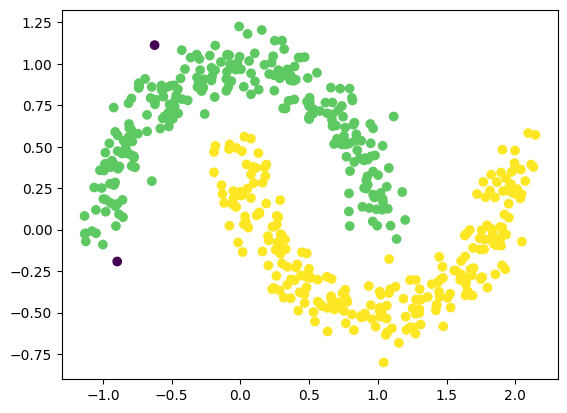

In [52]:
X, _ = make_moons(n_samples=500, noise=0.1)
sk_clusters = dbscan(eps=0.2, min_samples=10).fit_predict(X)
sk_clusters = [x+1
               if x != -1
               else x
               for x in sk_clusters]
plt.scatter(X[:,0], X[:,1], c=sk_clusters)
plt.show()

Reference (sklearn's DBSCAN):

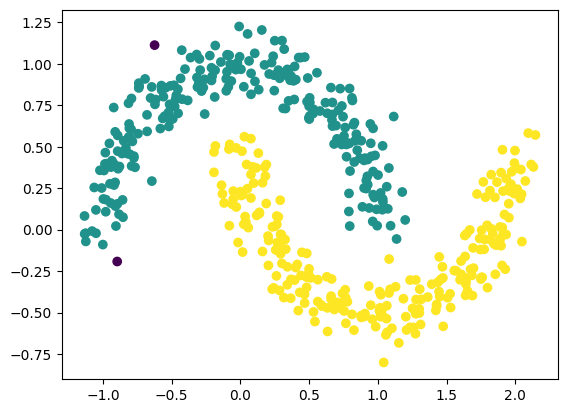

In [53]:
from sklearn.cluster import DBSCAN
#X, _ = make_moons(n_samples=500, noise=0.1)
clusters = DBSCAN(eps=0.2, min_samples=10).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=clusters)
plt.show()


> Also worth trying another interesting clustering example (use the provided image below as a reference -- aim for a couple of interesting adjacent shapes):



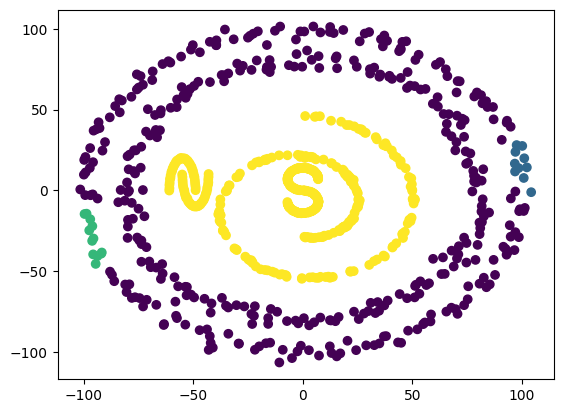

In [54]:
X, _ = make_circles(n_samples=400, noise=0.03, factor=0.8, random_state=None)
X1, _ = make_moons(n_samples=80, noise=0.01, random_state =None)
X1 *= 20
X1[:,0]=X1[:,0]*0.3 - 55
X2, _ = make_s_curve(n_samples=200, noise=0.01, random_state =None)
X3, _ = make_swiss_roll(n_samples=200, noise=0.1, random_state =None)
X3 = X3[:,[0,2]]
X *= 100
X2 = X2[:,[0,2]]
X3 *= 4
X3[:,1] = X3[:,1] - 10
X = np.append(X,X1, axis=0)
X = np.append(X,X2*7 , axis=0)
X = np.append(X,X3 , axis=0)

sk_clusters = dbscan(eps=10, min_samples=5).fit_predict(X)
sk_clusters = [x+1
               if x != -1
               else x
               for x in sk_clusters]
plt.scatter(X[:,0], X[:,1], c=sk_clusters)
plt.show()

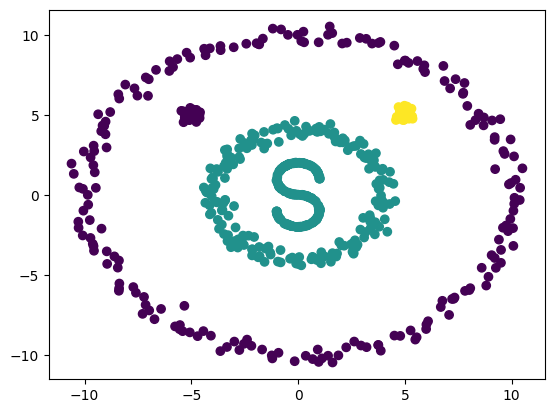

In [55]:
X, _ = make_circles(n_samples=400, noise=0.03, factor=0.4, random_state=None)
X2, _ = make_s_curve(n_samples=200, noise=0.01, random_state =None)
centers = [(-5,5), (5, 5)]
X3, _ = make_blobs(n_samples=100, centers=centers,cluster_std=0.2, random_state=None)


X*=10
X2 = X2[:,[0,2]]
X = np.append(X, X2, axis=0)
X = np.append(X, X3, axis=0)
sk_clusters = dbscan(eps=2, min_samples=5).fit_predict(X)
sk_clusters = [x+1
               if x != -1
               else x
               for x in sk_clusters]
plt.scatter(X[:,0], X[:,1], c=sk_clusters)
plt.show()


> Also worth comparing runtime against the reference implementation -- see how it holds up (roughly within 1000x, allowing for some measurement noise):



In [56]:
%%time
%%capture
clusters = DBSCAN(eps=0.2, min_samples=10).fit_predict(X)


CPU times: user 6.32 ms, sys: 1 ms, total: 7.32 ms
Wall time: 6.82 ms


In [57]:
%%time
%%capture
clusters = dbscan(eps=0.2, min_samples=10).fit_predict(X)

CPU times: user 4.01 s, sys: 8.38 ms, total: 4.02 s
Wall time: 4.5 s


## Applying DBSCAN

Take the `Distance` and `DepTime` columns (from the flight delay dataset). Run DBSCAN on the training set using them. Plot the resulting clusters as a scatter plot. How many clusters come out?

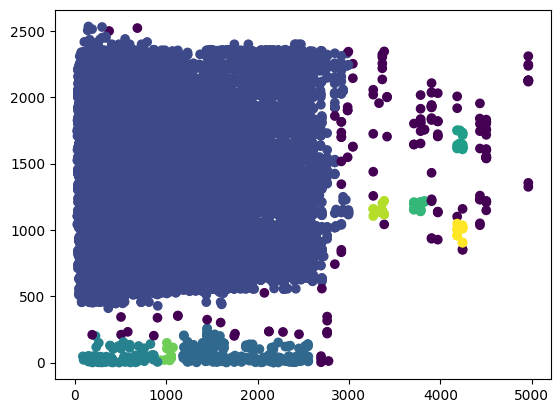

In [58]:
X_train = np.array(train[['Distance', 'DepTime']])
#X_train= pd.get_dummies(X_train, columns=['Month','DayofMonth','DayOfWeek', 'UniqueCarrier' ,'Origin','Dest'])
y_train = train['dep_delayed_15min'].map({'Y': 1, 'N': 0}).values


clusters = DBSCAN(eps=100, min_samples=15).fit_predict(X_train)
clusters = [x+1
               if x != -1
               else x
               for x in clusters]
plt.scatter(X_train[:,0], X_train[:,1], c=clusters)
plt.show()

In [59]:
X_train_part, X_valid, y_train_part, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=0)


eps= 0.1
min_samples= 3


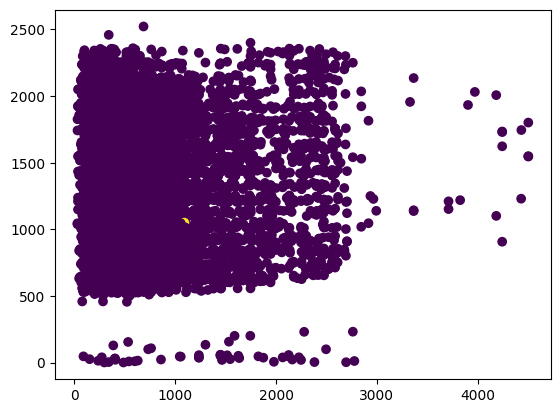

eps= 0.1
min_samples= 4


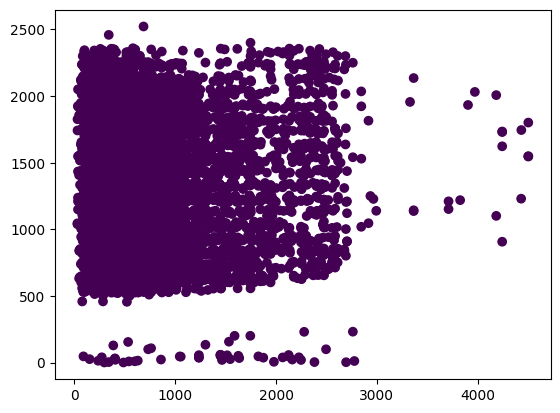

eps= 0.1
min_samples= 5


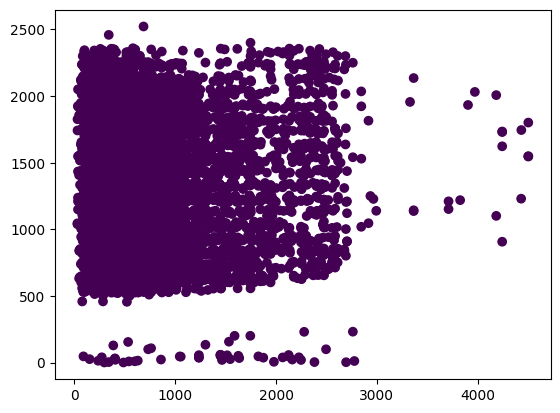

eps= 0.1
min_samples= 10


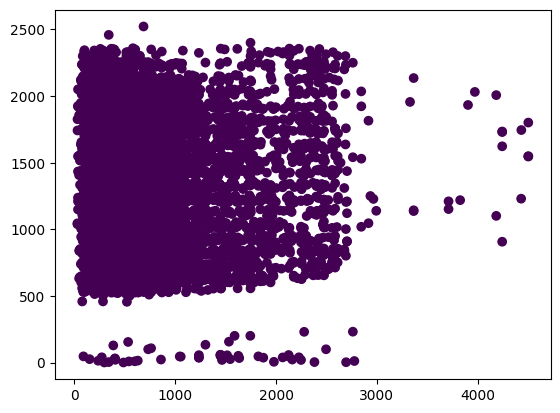

eps= 0.1
min_samples= 15


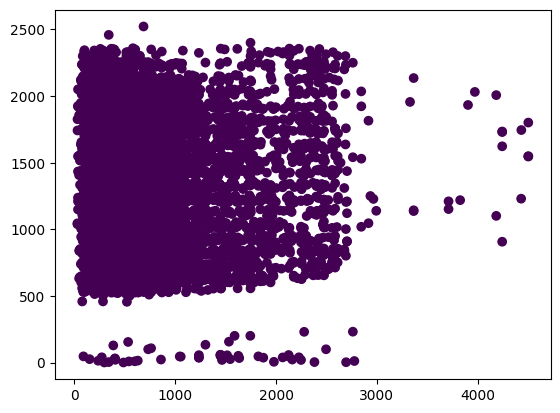

eps= 0.1
min_samples= 25


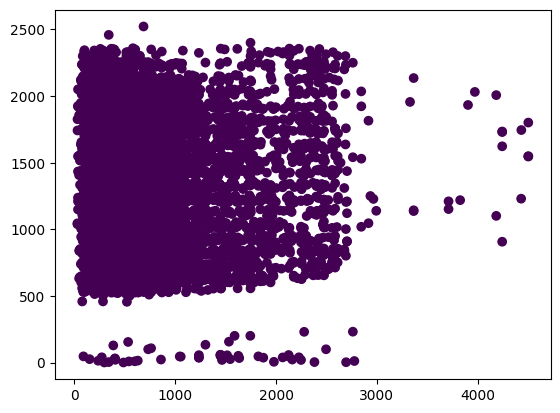

eps= 0.5
min_samples= 3


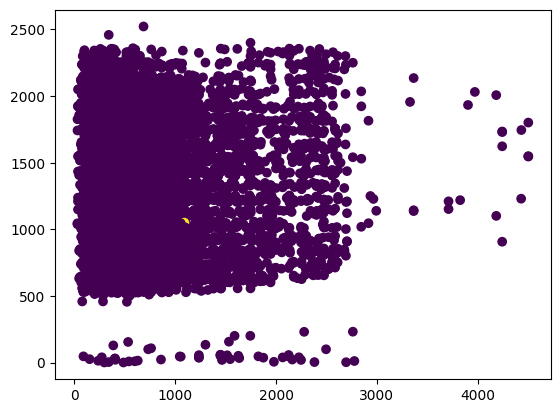

eps= 0.5
min_samples= 4


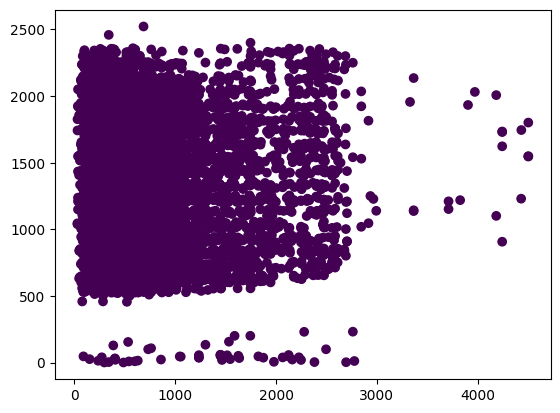

eps= 0.5
min_samples= 5


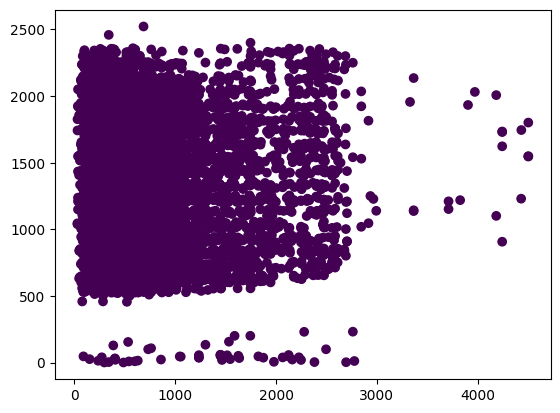

eps= 0.5
min_samples= 10


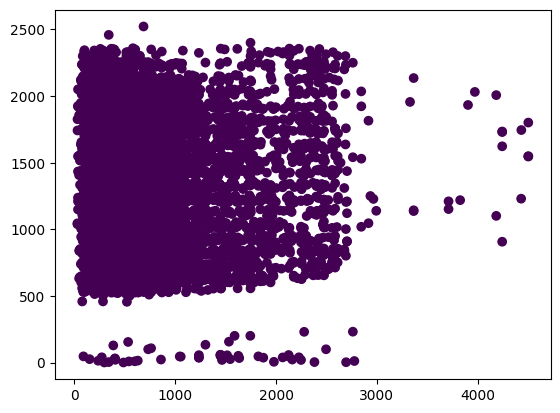

eps= 0.5
min_samples= 15


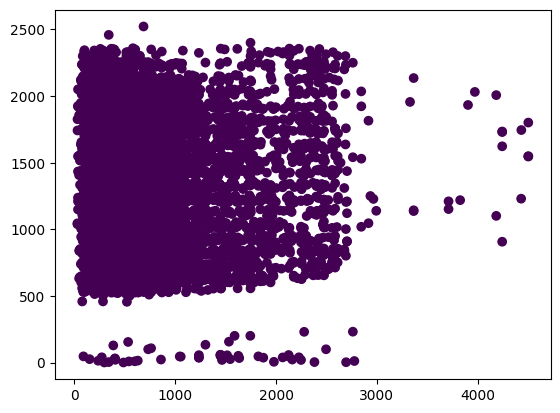

eps= 0.5
min_samples= 25


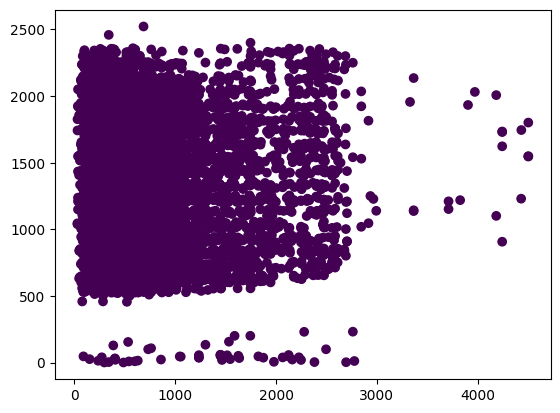

eps= 1
min_samples= 3


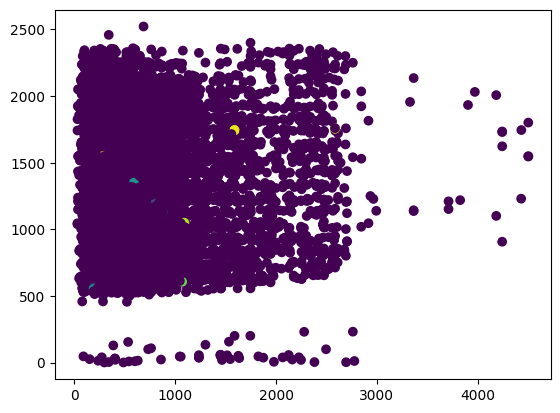

eps= 1
min_samples= 4


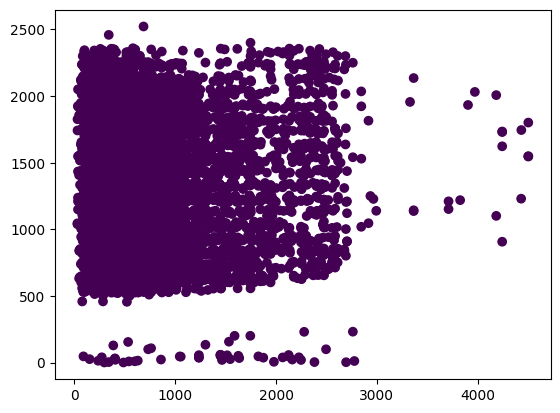

eps= 1
min_samples= 5


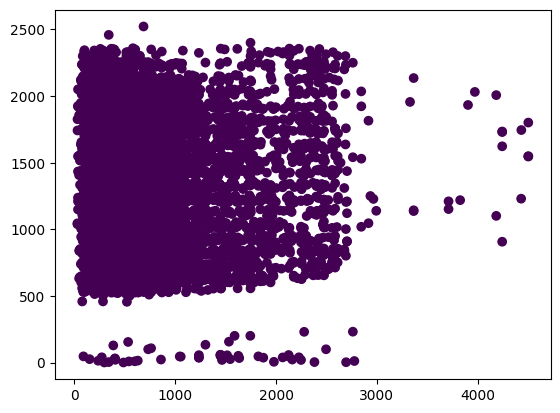

eps= 1
min_samples= 10


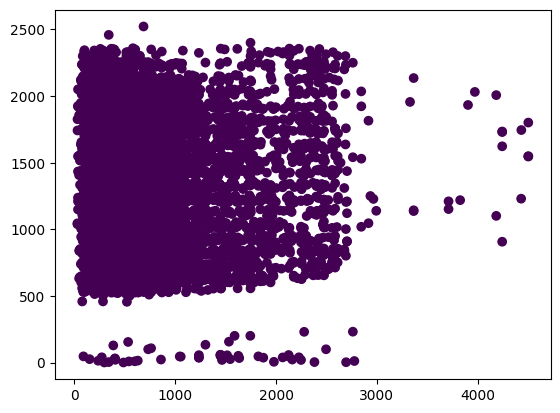

eps= 1
min_samples= 15


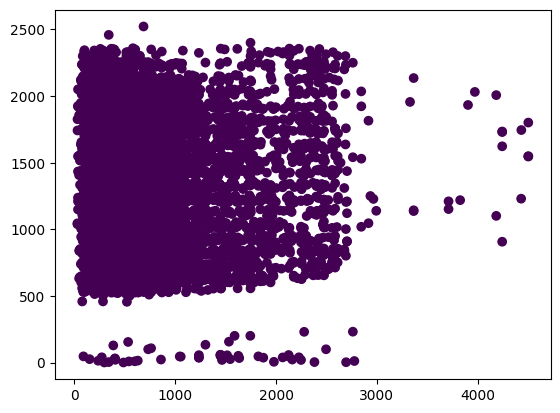

eps= 1
min_samples= 25


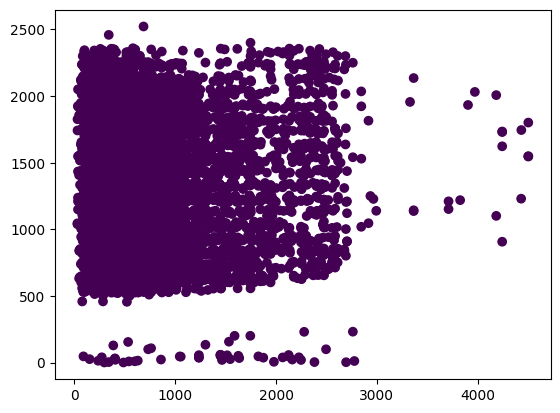

eps= 5
min_samples= 3


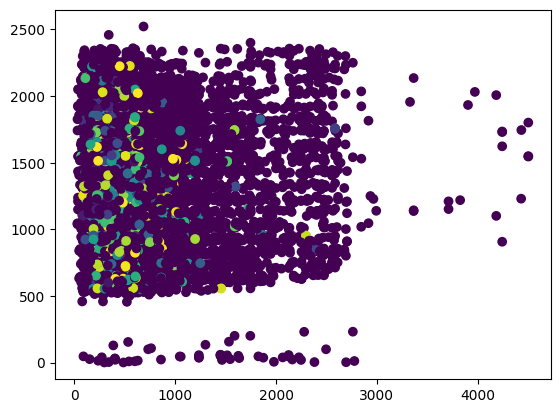

eps= 5
min_samples= 4


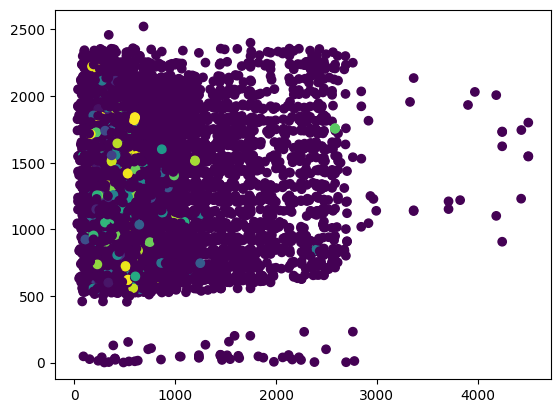

eps= 5
min_samples= 5


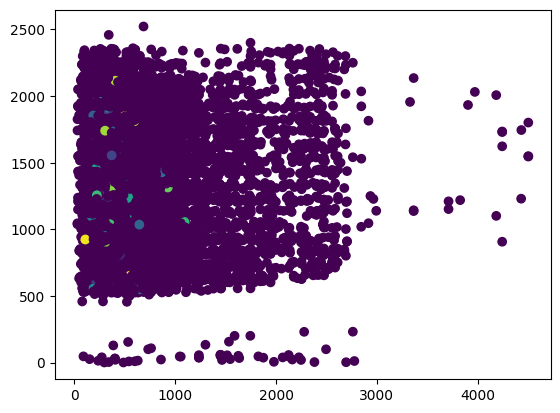

eps= 5
min_samples= 10


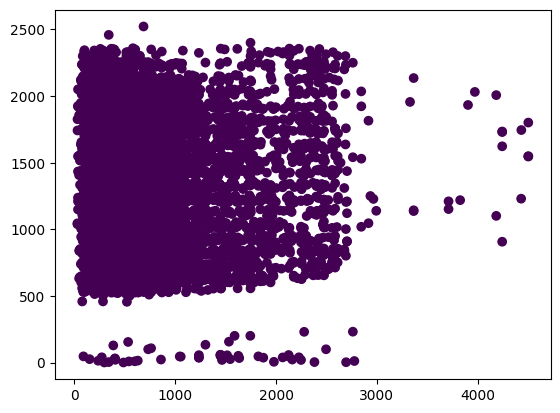

eps= 5
min_samples= 15


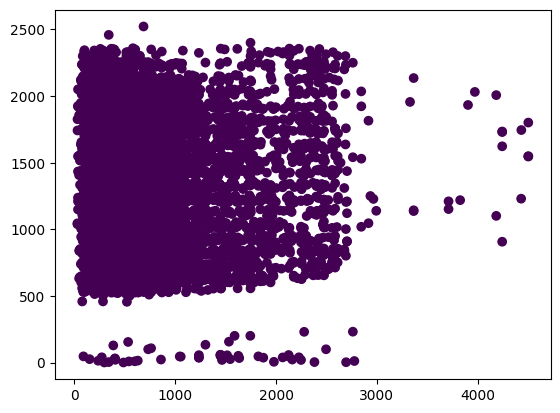

eps= 5
min_samples= 25


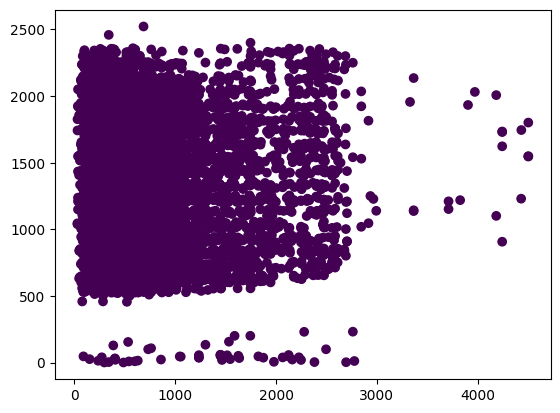

eps= 10
min_samples= 3


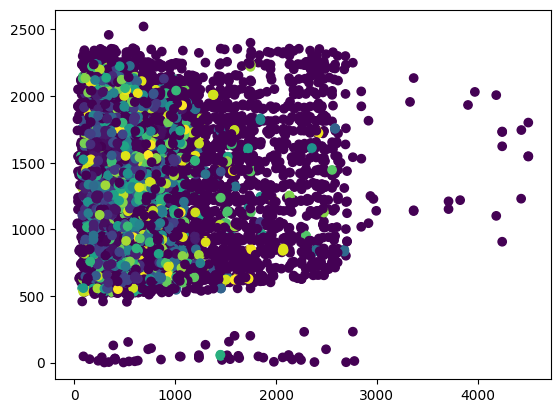

eps= 10
min_samples= 4


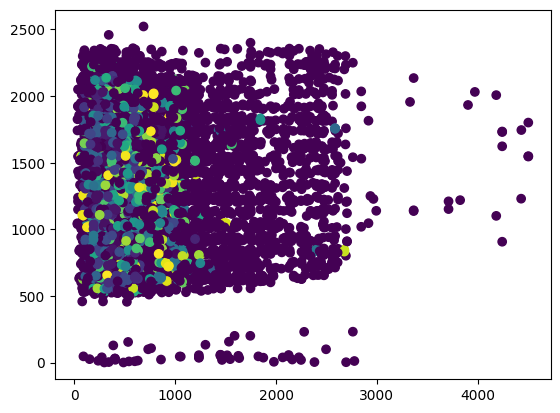

eps= 10
min_samples= 5


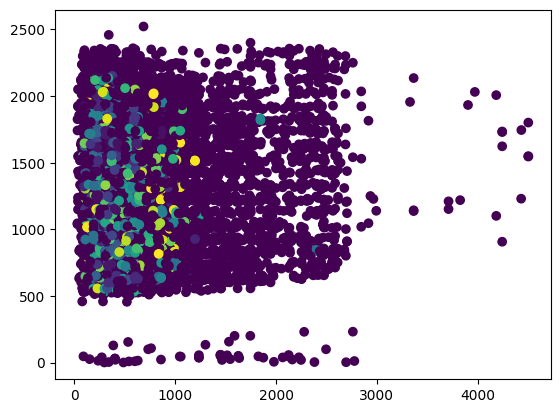

eps= 10
min_samples= 10


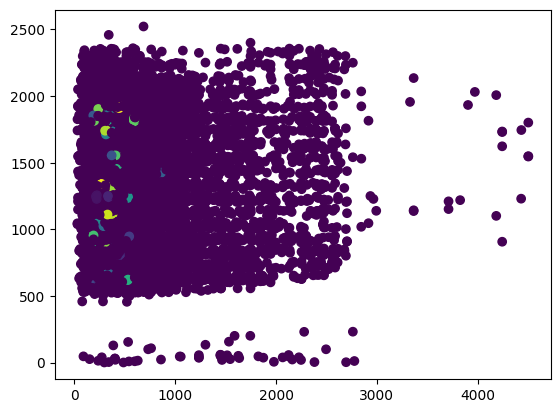

eps= 10
min_samples= 15


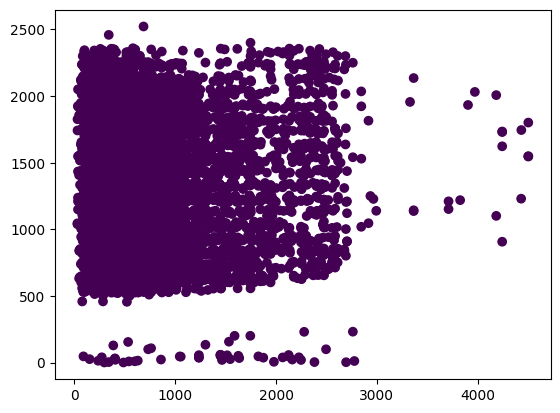

eps= 10
min_samples= 25


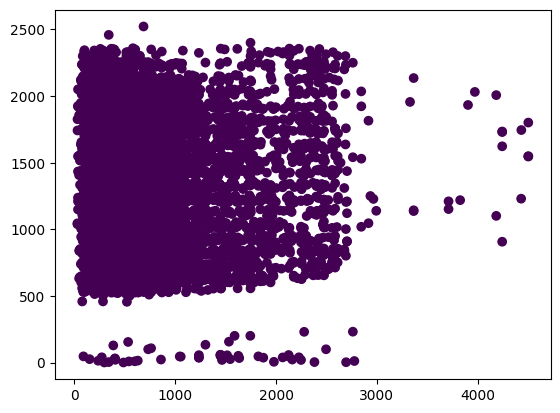

eps= 50
min_samples= 3


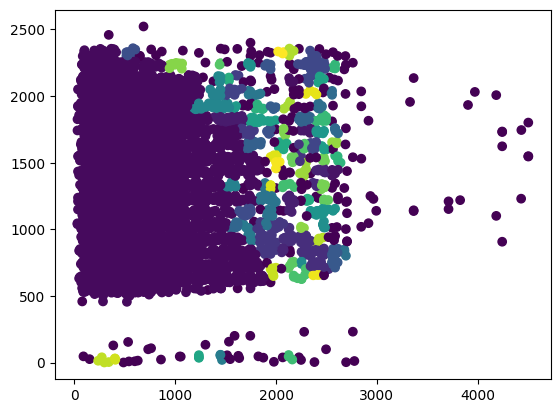

eps= 50
min_samples= 4


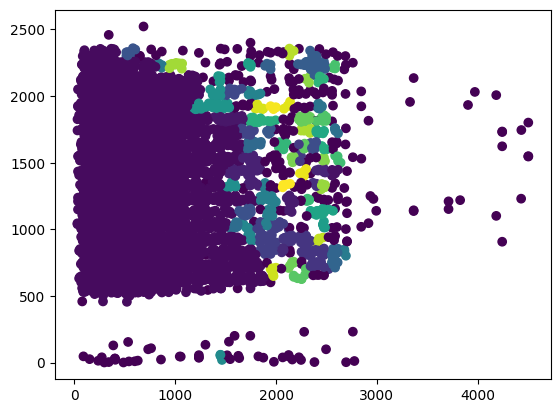

eps= 50
min_samples= 5


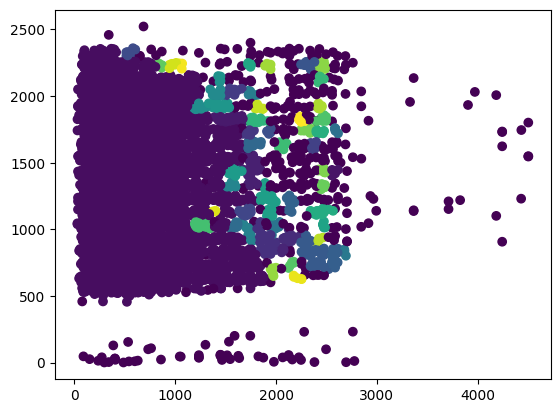

eps= 50
min_samples= 10


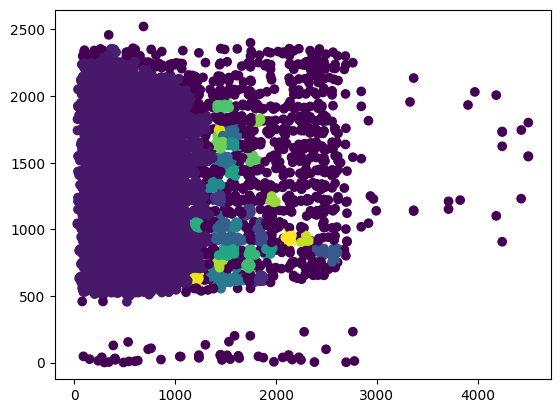

eps= 50
min_samples= 15


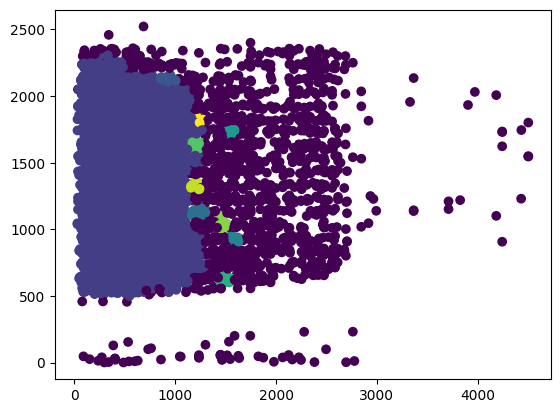

eps= 50
min_samples= 25


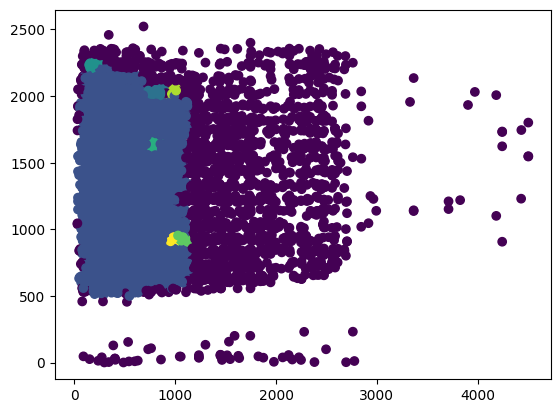

eps= 100
min_samples= 3


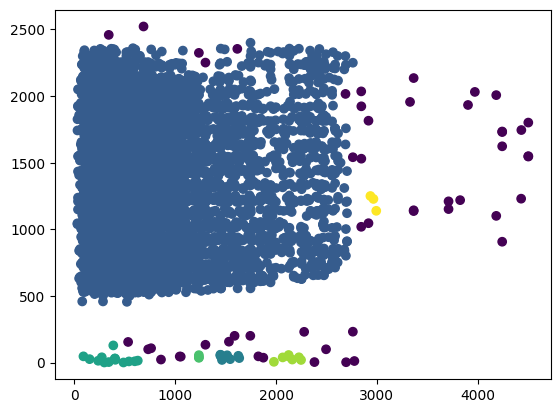

eps= 100
min_samples= 4


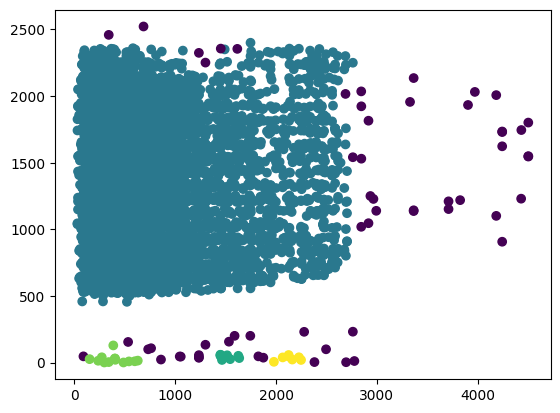

eps= 100
min_samples= 5


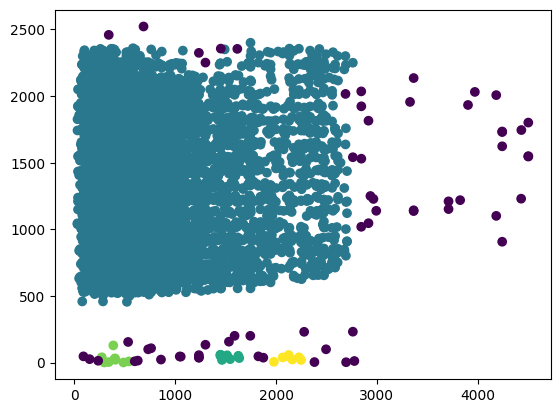

eps= 100
min_samples= 10


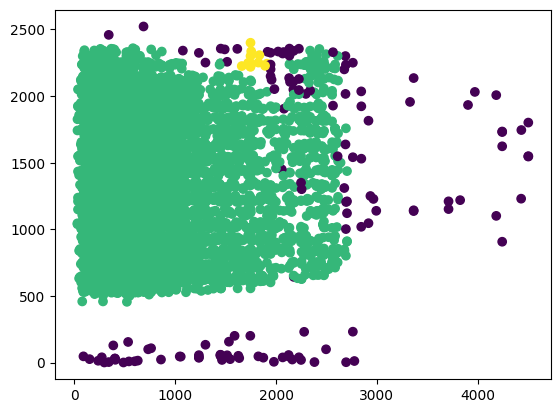

eps= 100
min_samples= 15


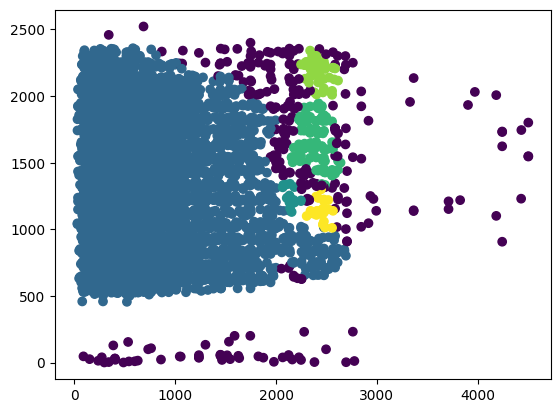

eps= 100
min_samples= 25


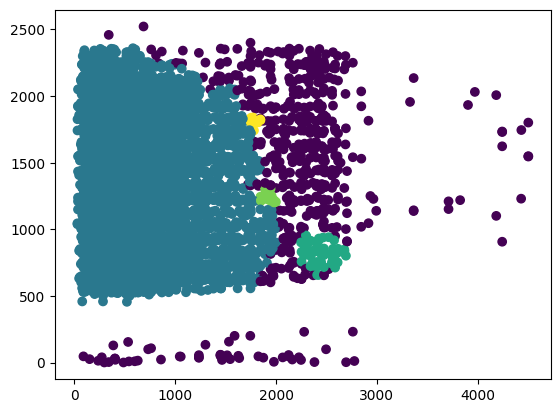

eps= 250
min_samples= 3


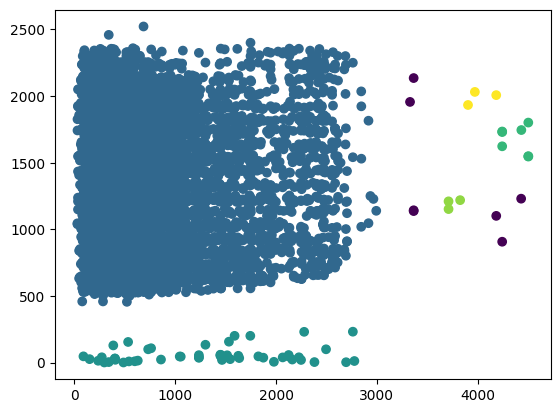

eps= 250
min_samples= 4


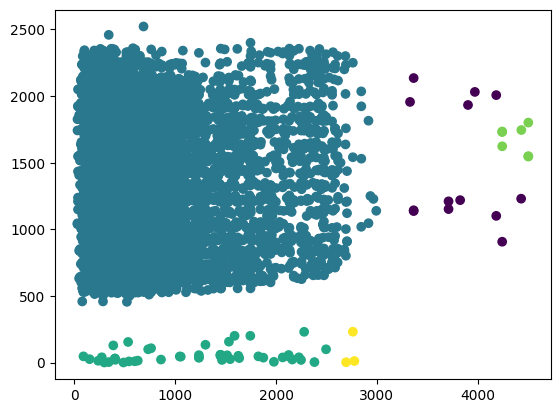

eps= 250
min_samples= 5


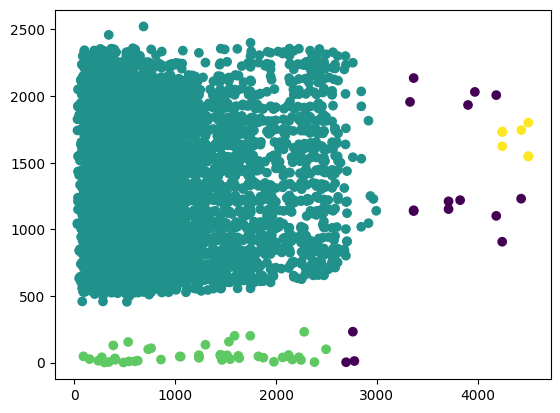

eps= 250
min_samples= 10


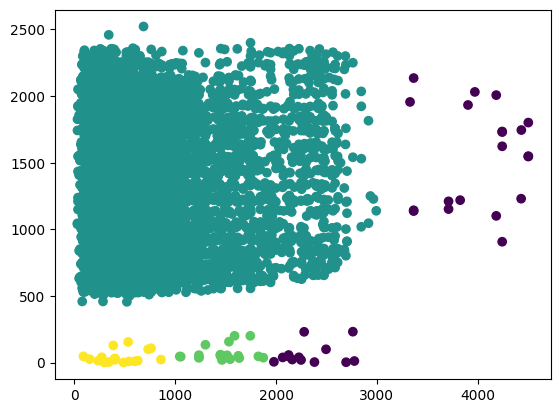

eps= 250
min_samples= 15


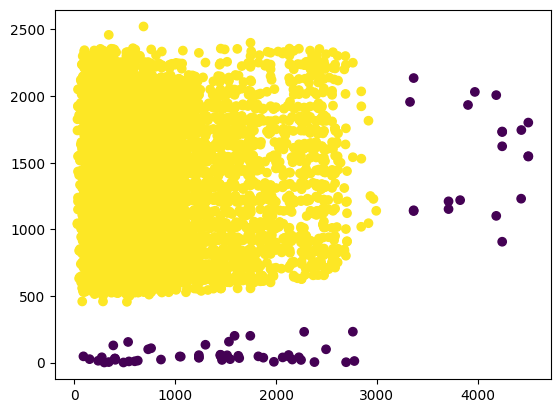

eps= 250
min_samples= 25


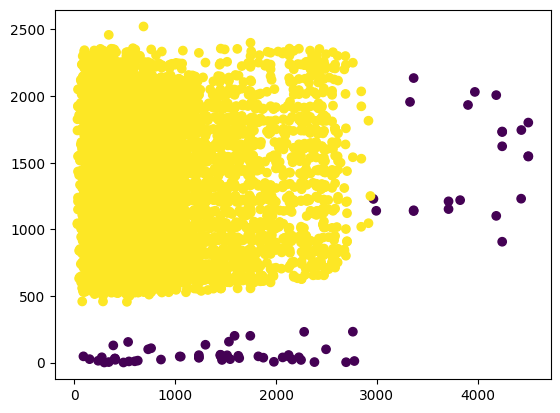

eps= 500
min_samples= 3


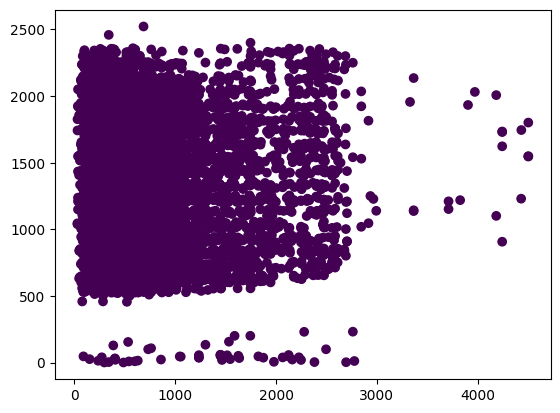

eps= 500
min_samples= 4


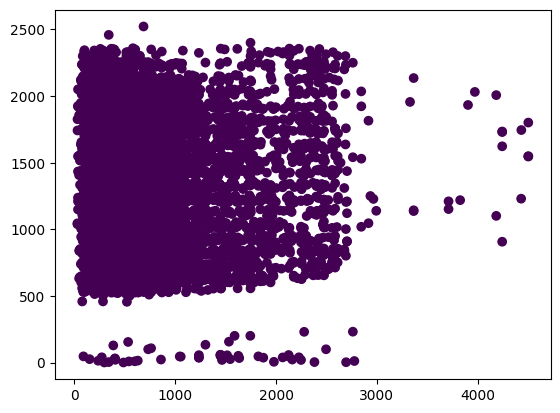

eps= 500
min_samples= 5


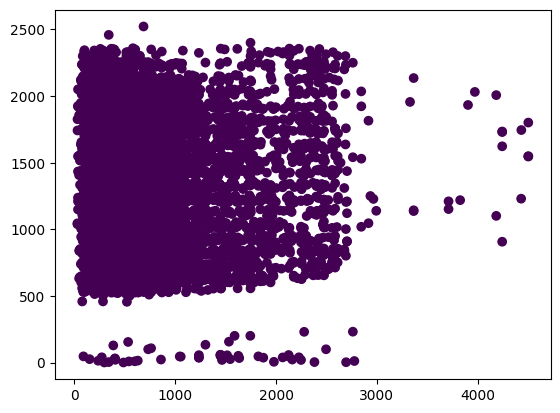

eps= 500
min_samples= 10


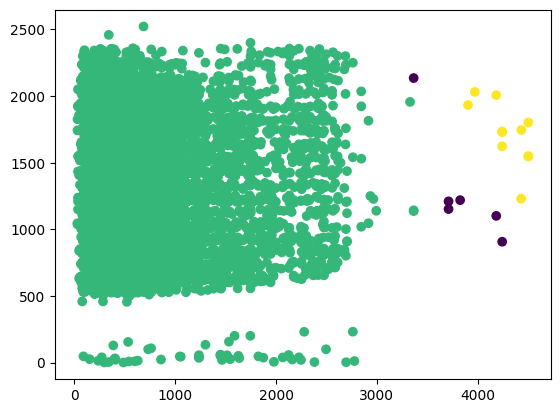

eps= 500
min_samples= 15


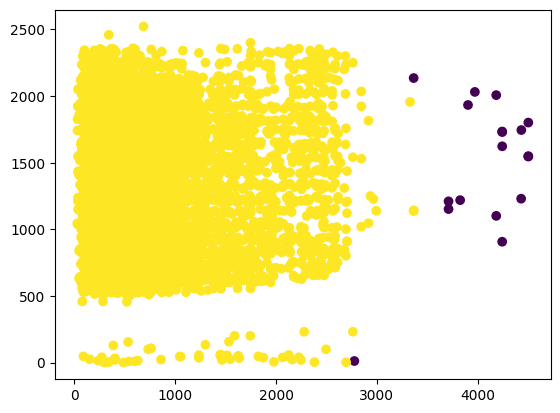

eps= 500
min_samples= 25


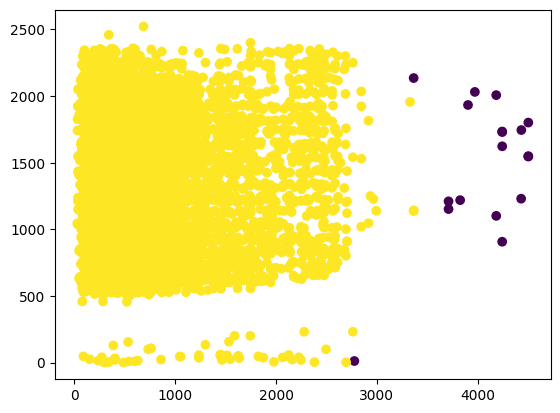

eps= 1000
min_samples= 3


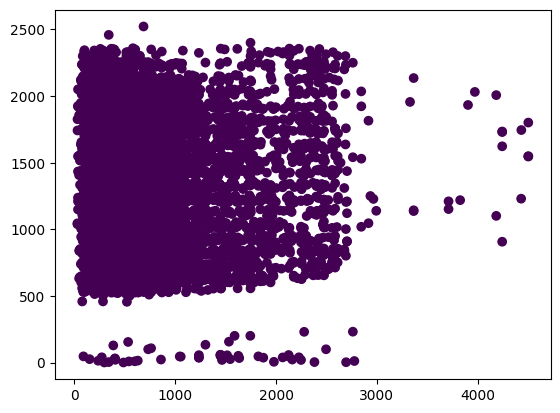

eps= 1000
min_samples= 4


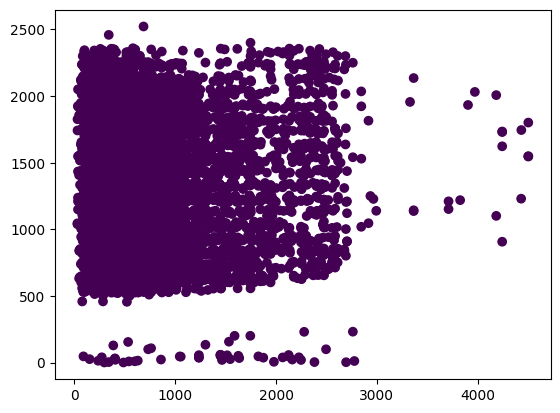

eps= 1000
min_samples= 5


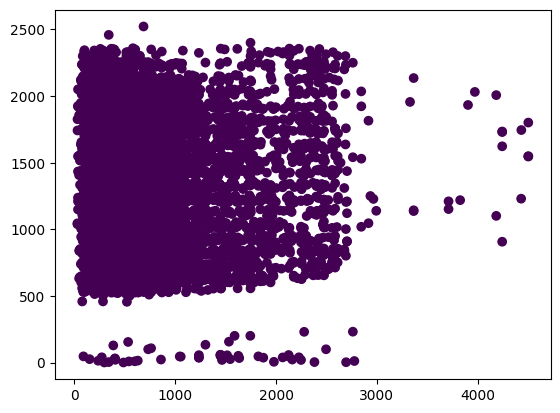

eps= 1000
min_samples= 10


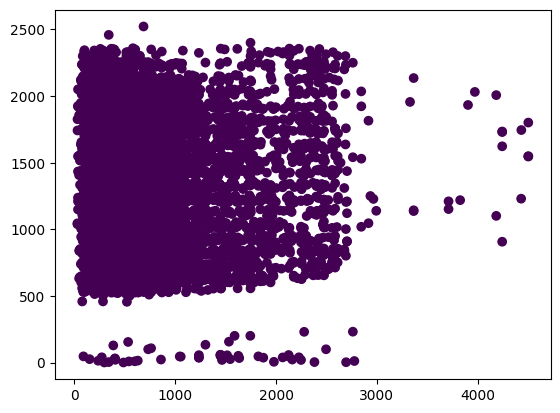

eps= 1000
min_samples= 15


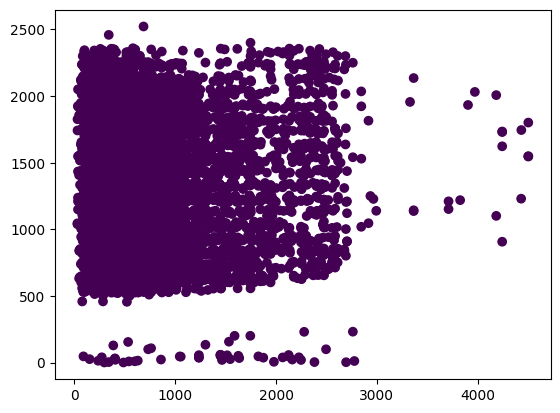

eps= 1000
min_samples= 25


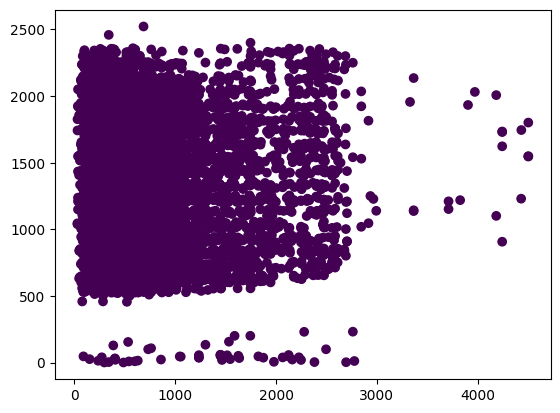

In [60]:
# With too small an eps (most of the data just doesn't cluster) and a high min_samples requirement,
# the most points end up labeled as noise
eps=[0.1, 0.5, 1, 5, 10, 50, 100, 250, 500, 1000]
min_samples=[3,4,5,10, 15, 25]
for elem in eps:
    for notelem in min_samples:
        clusters = DBSCAN(eps=elem,min_samples = notelem).fit_predict(X_valid)
        clusters = [x+1
               if x != -1
               else x
               for x in clusters]
        print('eps=', elem)
        print('min_samples=', notelem)
        plt.scatter(X_valid[:,0], X_valid[:,1], c=clusters)
        plt.show()